This notebook is for data loading/preparation and cleaning

In [1]:
import pandas as pd

In [2]:
# =========================
# 1) load data
# =========================
loads = pd.read_csv("raw_datasets/loads.csv")
routes = pd.read_csv("raw_datasets/routes.csv")
trips = pd.read_csv("raw_datasets/trips.csv")
fuel = pd.read_csv("raw_datasets/fuel_purchases.csv")
customers = pd.read_csv("raw_datasets/customers.csv") 

In [3]:
"""
Notes Arne:
The load type colum consists only of dry or refrigerated

We drop every row which has refrigerated as load type, 
because on our plattform we only want to offer pricing for dry loads right now.
"""

# =========================
# 2) define constants for column names
# =========================
# LOADS
LOAD_ID = "load_id"
LOAD_ROUTE_ID = "route_id"
LOAD_CUSTOMER_ID = "customer_id"
LOAD_REVENUE = "revenue"
LOAD_BOOKING_TYPE = "load_type"
LOAD_WEIGHT_LBS = "weight_lbs"
LOAD_NUMBER_OF_PIECES = "pieces"
LOAD_FUEL_SURCHARGE = "fuel_surcharge" 


# ROUTES
ROUTE_ID = "route_id"
ROUTE_DISTANCE_MILES = "typical_distance_miles"
ROUTE_ORIGIN = "origin_city"
ROUTE_DEST = "destination_city"
ROUTE_BASE_RATE_PER_MILE = "base_rate_per_mile" 
ROUTE_FUEL_SURCHARGE_PER_MILE = "fuel_surcharge_rate"

# TRIPS
TRIP_ID = "trip_id"
TRIP_LOAD_ID = "load_id"
TRIP_DURATION_HOURS = "actual_duration_hours"
TRIP_FUEL_CONSUMPTION = "fuel_consumption"

# FUEL_PURCHASES
FUEL_TRIP_ID = "trip_id"
FUEL_PRICE_PER_GALLON = "price_per_gallon"
FUEL_QUANTITY_GALLONS = "gallons"
FUEL_TOTAL_COST = "total_cost"

# CUSTOMERS
CUSTOMER_ID = "customer_id"
CUSTOMER_PRIMARY_FREIGHT_TYPE = "primary_freight_type"
CUSTOMER_ANNUAL_REVENUE_POTENTIAL = "annual_revenue_potential"

In [4]:
# =========================
# 3) preprocess fuel_purchases to get trip-level fuel features
# =========================
"""
Notes for the fuel_purchases table:
 - There are multiple fuel purchases per trip, so we need to aggregate them to the trip level.
 - we need to calculate the average gas_price_per_gallon, total quantity of gallons, and total cost for each trip.
"""

fuel_agg = fuel.groupby(TRIP_ID, as_index=False).agg(
    avg_fuel_price=(FUEL_PRICE_PER_GALLON, "mean"),
    total_fuel_quantity=(FUEL_QUANTITY_GALLONS, "sum"),
    total_fuel_cost=(FUEL_TOTAL_COST, "sum"),
)

fuel_agg.head()

,trip_id,avg_fuel_price,total_fuel_quantity,total_fuel_cost
0,TRIP00000001,3.845000,201.2,779.45
1,TRIP00000002,4.008000,187.8,752.70
2,TRIP00000003,4.041167,928.5,3796.39
3,TRIP00000005,3.682000,139.2,512.53
4,TRIP00000006,4.247400,771.5,3311.07


In [5]:
# =========================
# 4) TRIPS + FUEL MERGEN
# =========================
trips_with_fuel = trips.merge(fuel_agg, left_on=TRIP_ID, right_on=TRIP_ID, how="left")

In [6]:
#trips.head()
trips_with_fuel.head()

,trip_id,load_id,driver_id,truck_id,trailer_id,dispatch_date,actual_distance_miles,actual_duration_hours,fuel_gallons_used,average_mpg,idle_time_hours,trip_status,avg_fuel_price,total_fuel_quantity,total_fuel_cost
0,TRIP00000001,LOAD00000001,DRV00117,TRK00035,TRL00167,2022-01-01,1314,26.2,183.8,7.15,3.5,Completed,3.845000,201.2,779.45
1,TRIP00000002,LOAD00000002,DRV00141,TRK00108,TRL00082,2022-01-01,515,8.6,93.6,5.50,8.3,Completed,4.008000,187.8,752.70
2,TRIP00000003,LOAD00000003,DRV00032,TRK00031,TRL00138,2022-01-01,2509,45.0,339.1,7.40,12.0,Completed,4.041167,928.5,3796.39
3,TRIP00000004,LOAD00000004,DRV00083,TRK00105,TRL00018,2022-01-01,717,11.1,110.3,6.50,9.6,Completed,NaN,NaN,NaN
4,TRIP00000005,LOAD00000005,DRV00044,TRK00076,TRL00054,2022-01-01,2243,35.0,328.9,6.82,11.6,Completed,3.682000,139.2,512.53


In [7]:
# =========================
# 5) Only keep relevant columns for modeling
# =========================
loads_small = loads[
    [LOAD_ID, LOAD_ROUTE_ID, LOAD_CUSTOMER_ID, LOAD_REVENUE, LOAD_BOOKING_TYPE, LOAD_WEIGHT_LBS, LOAD_NUMBER_OF_PIECES, LOAD_FUEL_SURCHARGE]
].copy()

routes_small = routes[[ROUTE_ID, ROUTE_DISTANCE_MILES, ROUTE_ORIGIN, ROUTE_DEST, ROUTE_BASE_RATE_PER_MILE, ROUTE_FUEL_SURCHARGE_PER_MILE]].copy()

trips_small = trips_with_fuel[
    [
        TRIP_LOAD_ID,
        TRIP_DURATION_HOURS,
        "avg_fuel_price",
        "total_fuel_quantity",
        "total_fuel_cost",
    ]
].copy()

customers_small = customers[
    [CUSTOMER_ID, CUSTOMER_PRIMARY_FREIGHT_TYPE, CUSTOMER_ANNUAL_REVENUE_POTENTIAL]
].copy()

In [8]:
# =========================
# 6) JOIN LOADS, ROUTES, TRIPS, CUSTOMERS
# =========================
df = loads_small.merge(
    routes_small, left_on=LOAD_ROUTE_ID, right_on=ROUTE_ID, how="left"
)

df = df.merge(trips_small, left_on=LOAD_ID, right_on=TRIP_LOAD_ID, how="left")

df = df.merge(
    customers_small, left_on=LOAD_CUSTOMER_ID, right_on=CUSTOMER_ID, how="left"
)

In [9]:
# =========================
# 7) cleaning
# =========================
# Remove infinities
df = df.replace([float("inf"), float("-inf")], pd.NA)

# Treat missing values (for simplicity, we drop them here, but you could also impute them)
df = df.dropna(subset=[LOAD_REVENUE, ROUTE_DISTANCE_MILES, TRIP_DURATION_HOURS])

In [10]:
# =========================
# 8) Drop columns that won't be used for modeling
# =========================
# goal: pricing training table
# target = LOAD_REVENUE
drop_cols = [
    ROUTE_ID,
    TRIP_LOAD_ID,
    FUEL_TRIP_ID if FUEL_TRIP_ID in df.columns else None,
    CUSTOMER_ID if CUSTOMER_ID in df.columns else None,
]
drop_cols = [c for c in drop_cols if c is not None and c in df.columns]

pricing_df = df.drop(columns=drop_cols)


In [11]:
print(pricing_df.head() )

   revenue     load_type  weight_lbs  pieces  fuel_surcharge  \
0  3045.23       Dry Van       19178      13          406.72   
1  1224.48       Dry Van       27761      22           98.61   
2  7171.12  Refrigerated       35594      16          792.88   
3  1308.20  Refrigerated       33274      10          141.33   
4  3317.18       Dry Van       40257      10          738.48   

   typical_distance_miles  origin_city destination_city  base_rate_per_mile  \
0                    1271      Houston          Detroit                2.33   
1                     519  Kansas City     Indianapolis                2.27   
2                    2332     Columbus         Portland                2.69   
3                     673      Phoenix           Denver                1.70   
4                    2172      Houston          Seattle                1.77   

   fuel_surcharge_rate  actual_duration_hours  avg_fuel_price  \
0                 0.32                   26.2        3.845000   
1         

In [23]:
# =========================
# 9) Apply australian market specific transformations (e.g., convert miles to kilometers, pounds to kilograms, gallons to liters, etc.)
# =========================


POUNDS_TO_KG = 0.45359237
MILES_TO_KM = 1.60934
GALLONS_TO_LITERS = 3.78541
USD_TO_AUD = 1.5
EXTRA_FUEL_MULTIPLIER_AUSTRALIAN_MARKET = 1.25 # 25% extra fuel cost in the australian market
EXTRA_PRICING_MULTIPLIER_AUSTRALIAN_MARKET = 1.15 # we want to have 15% higher prices in the australian market to account for higher costs and lower price sensitivity

# 0.45359237 pounds in a kilogram
pricing_df["weight_kg"] = pricing_df[LOAD_WEIGHT_LBS] * POUNDS_TO_KG
pricing_df["distance_km"] = pricing_df[ROUTE_DISTANCE_MILES] * MILES_TO_KM
pricing_df["fuel_quantity_liters"] = pricing_df["total_fuel_quantity"] * GALLONS_TO_LITERS

# avg_fuel_price = usd/gallon -> aud per liter (1 USD = 1.5 AUD, 1 gallon = 3.78541 liters)
pricing_df["avg_fuel_price_aud_per_liter"] = (
    pricing_df["avg_fuel_price"] * USD_TO_AUD / GALLONS_TO_LITERS * EXTRA_FUEL_MULTIPLIER_AUSTRALIAN_MARKET
)
# total_fuel_cost in USD -> total_fuel_cost in AUD
pricing_df["total_fuel_cost_aud"] = (
    pricing_df["total_fuel_cost"] * USD_TO_AUD * EXTRA_FUEL_MULTIPLIER_AUSTRALIAN_MARKET
)

# revenue in USD -> revenue in AUD
pricing_df["revenue_aud"] = pricing_df[LOAD_REVENUE] * USD_TO_AUD * EXTRA_PRICING_MULTIPLIER_AUSTRALIAN_MARKET
# fuel surcharge in USD -> fuel surcharge in AUD
pricing_df["fuel_surcharge_aud"] = pricing_df[LOAD_FUEL_SURCHARGE] * USD_TO_AUD * EXTRA_PRICING_MULTIPLIER_AUSTRALIAN_MARKET
# base_rate_per_mile in USD -> base_rate_per_km in AUD
pricing_df["base_rate_per_km_aud"] = (pricing_df[ROUTE_BASE_RATE_PER_MILE] * USD_TO_AUD) / MILES_TO_KM * EXTRA_PRICING_MULTIPLIER_AUSTRALIAN_MARKET
# annual_revenue_potential in USD -> annual_revenue_potential in AUD
pricing_df["annual_revenue_potential_aud"] = pricing_df["annual_revenue_potential"] * USD_TO_AUD * EXTRA_PRICING_MULTIPLIER_AUSTRALIAN_MARKET

drop_cols = [
    LOAD_WEIGHT_LBS,
    ROUTE_DISTANCE_MILES,
    "total_fuel_quantity",
    "avg_fuel_price",
    LOAD_REVENUE,
    LOAD_FUEL_SURCHARGE,
    ROUTE_BASE_RATE_PER_MILE,
    "total_fuel_cost",
    "annual_revenue_potential",
]

pricing_df = pricing_df.drop(columns=drop_cols)

print(pricing_df.columns)

KeyError: 'weight_lbs'

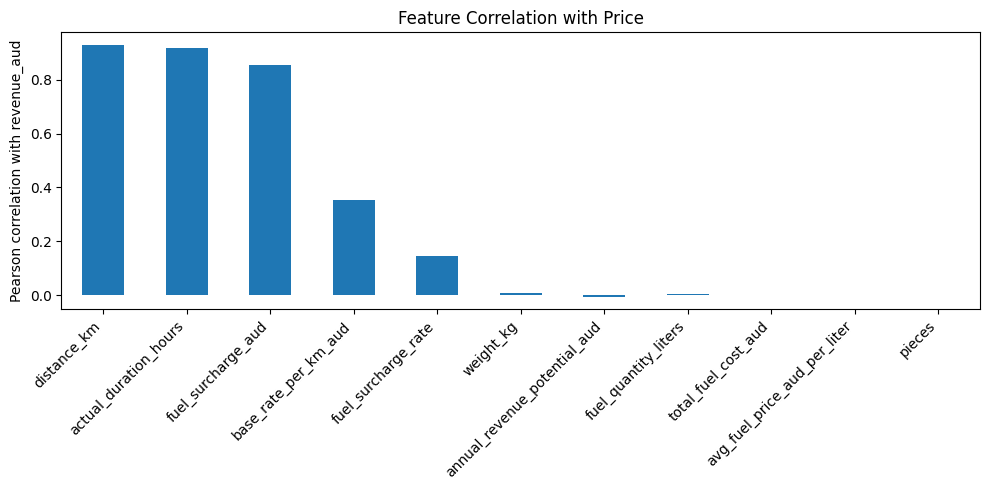

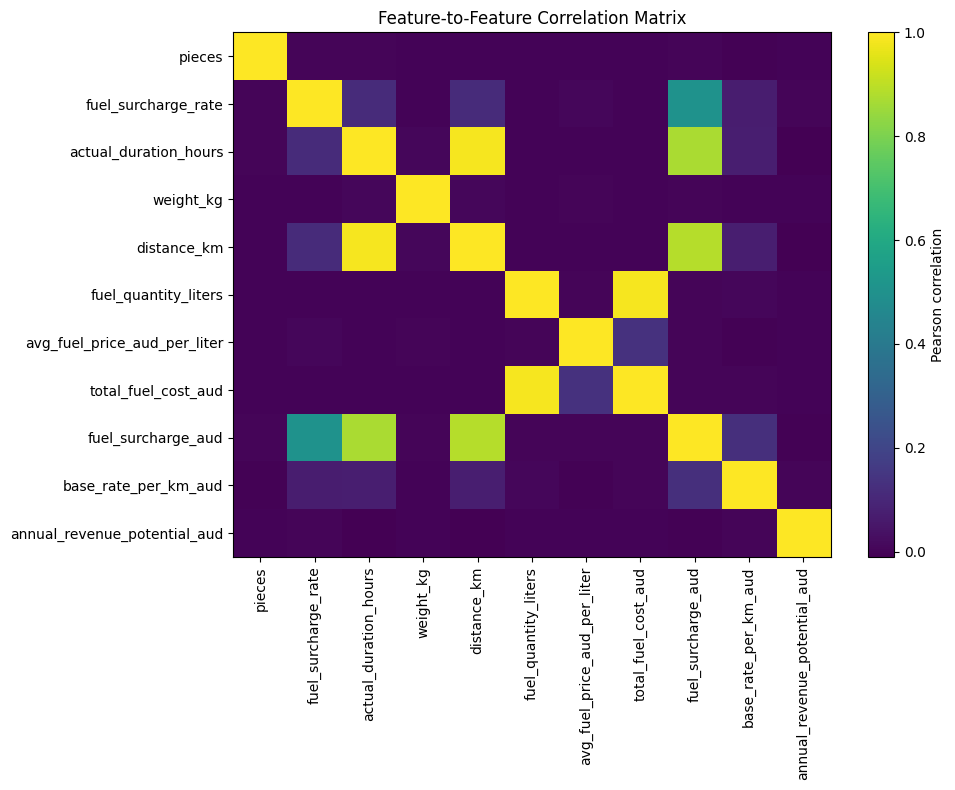

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# df = your dataframe
target = "revenue_aud"

numeric_cols = pricing_df.select_dtypes(include="number").columns.tolist()

# -----------------------------
# 1) Correlation: features vs price
# -----------------------------
price_corr = (
    pricing_df[numeric_cols].corr()[target].drop(target).sort_values(key=abs, ascending=False)
)

plt.figure(figsize=(10, 5))
price_corr.plot(kind="bar")
plt.title("Feature Correlation with Price")
plt.ylabel("Pearson correlation with revenue_aud")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


# -----------------------------
# 2) Correlation: features with each other
# -----------------------------
feature_corr = pricing_df[numeric_cols].drop(columns=[target]).corr()

plt.figure(figsize=(10, 8))
plt.imshow(feature_corr, aspect="auto")
plt.colorbar(label="Pearson correlation")
plt.xticks(range(len(feature_corr.columns)), feature_corr.columns, rotation=90)
plt.yticks(range(len(feature_corr.columns)), feature_corr.columns)
plt.title("Feature-to-Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [17]:
# generate statistics number of loads

#average distance
avg_distance = pricing_df["distance_km"].mean()

#average revenue
avg_revenue = pricing_df["revenue_aud"].mean()

#average revenue per km
avg_revenue_per_km = avg_revenue / avg_distance if avg_distance else 0

#average fuel cost
avg_fuel_cost = pricing_df["total_fuel_cost_aud"].mean()

print(f"Number of loads: {len(pricing_df)}")
print(f"Average distance (km): {avg_distance:.2f}")
print(f"Average revenue (AUD): {avg_revenue:.2f}")
print(f"Average revenue per km (AUD/km): {avg_revenue_per_km:.2f}")
print(f"Average fuel cost (AUD): {avg_fuel_cost:.2f}")

Number of loads: 85410
Average distance (km): 2235.81
Average revenue (AUD): 5302.15
Average revenue per km (AUD/km): 2.37
Average fuel cost (AUD): 2329.60


In [13]:
# =========================
# 10) Save processed dataset
# =========================
pricing_df.to_csv("processed_datasets/pricing_training_table.csv", index=False)

print(pricing_df.head())
print(pricing_df.shape)

   revenue     load_type  weight_lbs  pieces  fuel_surcharge  \
0  3045.23       Dry Van       19178      13          406.72   
1  1224.48       Dry Van       27761      22           98.61   
2  7171.12  Refrigerated       35594      16          792.88   
3  1308.20  Refrigerated       33274      10          141.33   
4  3317.18       Dry Van       40257      10          738.48   

   typical_distance_miles  origin_city destination_city  base_rate_per_mile  \
0                    1271      Houston          Detroit                2.33   
1                     519  Kansas City     Indianapolis                2.27   
2                    2332     Columbus         Portland                2.69   
3                     673      Phoenix           Denver                1.70   
4                    2172      Houston          Seattle                1.77   

   fuel_surcharge_rate  actual_duration_hours  avg_fuel_price  \
0                 0.32                   26.2        3.845000   
1         

operating Costs for an american truck: 
https://truckingresearch.org/2025/07/new-atri-report-shows-trucking-profitability-severly-squeezed-by-high-costs-low-rates/

$2.260 per mile -> 1.40 $ per km ~ 2.10 AUD per km

operating Costs Australia (victoria):
https://www.vic.gov.au/owner-driver-rates-and-costs-schedules/semi-trailer-bogie-drive-6-axle-2024-25

Variable Kosten: $1,50Fixkosten & Lohn: $0,84Gesamtkosten: $2,34 AUD pro Kilometer.

=> 10%

Operating Costs: +10 % (Fakt durch Behördendaten).Endpreis (Marktpreis): ~ +15 % (wegen geringerem Wettbewerb und höheren Margen).

=> 15%


(nachschauen wie viel teurer sprit ist und das dann auch konvertieren)
https://thehill.com/policy/energy-environment/5787562-diesel-gas-prices-iran-conflict-oil/
3.65 US  per gallon

https://www.accc.gov.au/media-release/accc-keeping-a-close-eye-on-petrol-market-amid-middle-east-conflict

~180 Cent per Liter ~ $4,65 per Gallon

=> ~25% mehr


Die Paletten daten von truckinet nehmen und damit ein paar Beispiele bauen#
https://www.truckit.net/pallets-and-packages
